In [1]:
# Restore all previously stored variables
%store -r plots_dir hygrolon_area c_hygrolon n_hygrolon isopod_c_n_ratio isopod_c isopod_n springtail_c_n_ratio springtail_c springtail_n 
%store -r moss_c_n_ratio moss_c moss_n

In [2]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# For scientific computing
import numpy as np # To work with arrays
from scipy.integrate import odeint # To solve ordinary differential equations (ODEs)

# For visualization and interactive plotting
import matplotlib.pyplot as plt # To import the Pyplot module
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset # To create an inset axis

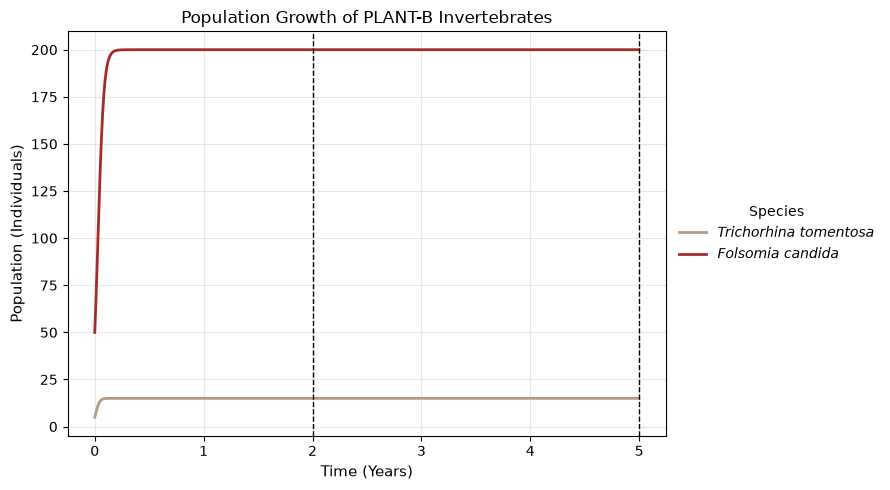

In [17]:
# Give the timeframe (in days)
total_days = 365 * 5 # Five years in total
t = np.arange(total_days)

# Define population parameters for the two invertebrates:
# Isopod population parameters
isopods = 5 # Starting number of isopod individuals
isopod_carrying_capacity = 15 # Placeholder isopod carrying capacity for the terrarium
isopod_fecundity = 0.164 # Average daily fecundity (by eggs laid) of a close relative (Heeley, 1941)
isopod_mortality = 0.0011 # Calculated from an assumed average lifespan of 2.5 years

# Model the isopod population growth over time
isopod_growth_rate = isopod_fecundity - isopod_mortality # Define the daily growth rate for the isopods
isopod_population = isopod_carrying_capacity / (1 + ((isopod_carrying_capacity - isopods) / isopods) * np.exp(-isopod_growth_rate * t))

# Springtail population parameters
springtails = 50 # Starting number of springtail individuals
springtail_carrying_capacity = 200 # Placeholder springtail carrying capacity for the terrarium
springtail_fecundity = 0.109 # Average daily fecundity of adult springtails (Xie et al., 2026)
springtail_mortality = 0.00734 # Average daily mortality of the springtails at 21°C (Snider & Butcher, 1973)

# Model the springtail population growth over time
springtail_growth_rate = springtail_fecundity - springtail_mortality # Define the daily growth rate for the springtails
springtail_population = springtail_carrying_capacity / (1 + ((springtail_carrying_capacity - springtails) / springtails) * 
                                                        np.exp(-springtail_growth_rate * t))

# Create a function that plots the invertebrate population growth over five years:
def population_growth_plot(t, isopod_population, springtail_population):
    """
    Parameters:
    t (array): Time values in days across five years
    isopod_population: Growing isopod population count over time
    springtail_population: Growing springtail population count over time

    Returns:
    A line chart that shows the isopod and springtail population growth curves over the five-year timeframe
    """
    # Label the population curves and set their colors
    species_colors = {
        "Trichorhina tomentosa": "#B19C86", # Weathered wood the white dwarf isopod
        # Dark orange for the temperate white springtail
        "Folsomia candida": "#A52A2A" # Reddish-brown for the temperate white springtail
    }

    # Convert the day-based time array to years for the x-axis
    years = t / 365

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot the isopod population growth curve
    ax.plot(
        years,
        isopod_population,
        color=species_colors["Trichorhina tomentosa"], # Ensure the isopod keeps its designated color
        label=r"$\it{Trichorhina\ tomentosa}$", # Italicize the isopod's scientific name
        linewidth=2
    )

    # Plot the springtail population growth curve
    ax.plot(
        years,
        springtail_population,
        color=species_colors["Folsomia candida"], # Ensure the springtail keeps its designated color
        label=r"$\it{Folsomia\ candida}$", # Italicize the springtail's scientific name
        linewidth=2
    )

    # Set the title
    ax.set_title("Population Growth of PLANT-B Invertebrates", fontsize=12)

    # Label the x- and y-axis and set their font size
    ax.set_xlabel("Time (Years)", fontsize=11)
    ax.set_ylabel("Population (Individuals)", fontsize=11)

    # Mark the two- and five-year intervals on the plot
    plt.axvline(2, color='black', linestyle='--', linewidth=1) # For two years
    plt.axvline(5, color='black', linestyle='--', linewidth=1) # For five years

    # Create a legend titled "Species" and anchor it to the right
    ax.legend(title='Species', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

    # Add gridlines for readability
    ax.grid(True, alpha=0.3)

    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Invertebrate_Population_Growth_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Display the plot
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = population_growth_plot(
    t,
    isopod_population,
    springtail_population
)

C:\Users\livth\AppData\Local\Temp\ipykernel_27104\944467620.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


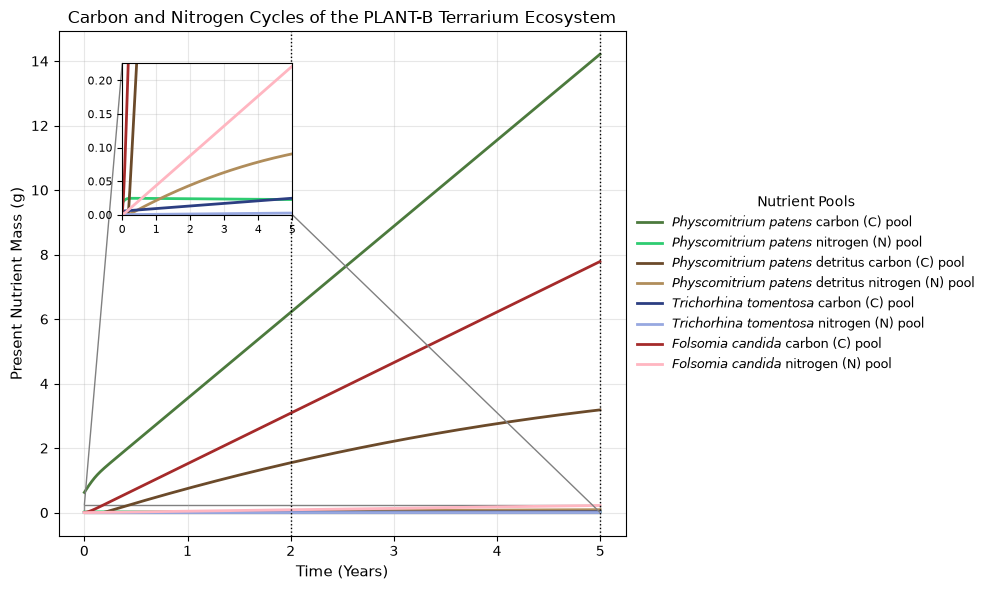

In [27]:
# Define population parameters for the three species:
# Moss population parameters
# Starting moss biomass per cm² calculated from given mass in a 90 mm diameter Petri dish (Cove et al., 2009)
moss_starting_biomass = (0.2 / 58) * hygrolon_area 
# Add a placeholder biomass cap (g)
moss_biomass_cap = 15
# Relative growth rate (RGR) of a closely related moss species (g/day) (Glime, 2021)
moss_rgr = 0.05 * moss_starting_biomass
# Daily carbon intake of a separate moss species (g/cm²/day) (Aro et al., 1984)
moss_c_intake = 0.0000363 
# Cap is equal to daily carbon sequestration capacity of a moss system (g/cm²) times the Hygrolon surface area (cm²) (Kim et al., 2025)
moss_c_intake_cap = 0.00008219178 * hygrolon_area 
# Average daily nitrogen intake rate (g) for mosses (Ayres et al., 2006)
moss_n_deposition_rate = 0.00000051 * hygrolon_area

# Create an equation to map the total moss biomass
moss_biomass = moss_biomass_cap / (
    1 + ((moss_biomass_cap - moss_starting_biomass) / moss_starting_biomass)
    * np.exp(-moss_rgr * t)
)

# Calculate the moss carbon intake rate
moss_c_intake_rate = np.minimum(moss_c_intake * hygrolon_area, moss_c_intake_cap)

# Calculate starting moss carbon (g)
starting_moss_c = moss_starting_biomass * (moss_c / 100) # Starting carbon quantity of 0.30620689636 g

# Calculate starting moss nitrogen (g)
starting_moss_n = moss_starting_biomass * (moss_n / 100) # Starting nitrogen quantity of 0.00868965516 g

# Leaf litter values
moss_senescence = (moss_biomass * 0.395) / 365 # Average daily biomass turnover (Laiho et al., 2011)
k = 0.055 / 365 # K represents the daily decomposition constant of moss leaf litter (Lang et al., 2009) 
# No leaf litter will exist at the beginning of the simulation`
starting_litter_mass = 0 
starting_litter_c = 0
starting_litter_n = 0

# Calculate the mass loss for the leaf litter in g/day
litter_mass = np.zeros(total_days)
litter_mass[0] = starting_litter_mass
for i in range(1, total_days):
    litter_mass[i] = litter_mass[i-1] + moss_senescence[i-1] - (k * litter_mass[i-1])
litter_decomposition_flux = k * litter_mass

# Calculate the carbon and nitrogen content of the litter pool in g
litter_c = litter_mass * (moss_c / 100)  # Carbon in litter pool (g)
litter_n = litter_mass * (moss_n / 100)   # Nitrogen in litter pool (g)

# Quantify carbon and nitrogen gains the litter sees over time
litter_c_senescence = moss_senescence * (moss_c / 100) # For carbon
litter_n_senescence = moss_senescence * (moss_n / 100) # For nitrogen

# Quantify how much carbon and nitrogen the litter loses through decomposition
litter_c_decomposition = litter_decomposition_flux * (moss_c / 100) # For carbon
litter_n_decomposition = litter_decomposition_flux * (moss_n / 100) # For nitrogen

# Simulate carbon and nitrogen cycles in the moss subsystem
moss_c_flux = starting_moss_c + np.cumsum(moss_c_intake_rate - litter_c_senescence)
moss_n_flux = starting_moss_n + np.cumsum(moss_n_deposition_rate - litter_n_senescence)

# Isopod population parameters
isopod_mass = 0.01022/3 # Average mass (g) of a close relative of the isopod (Bílá et al., 2014)
isopod_consumption = 0.002 * isopod_mass # Average daily litter consumption (g) of a close relative of the isopod (El-Wakeil, 2015)
isopod_c_excretion = (0.0025 * 0.2729) * isopod_mass # Average daily carbon lost from respiration in a close relative (Smigel & Gibbs, 2006)
isopod_n_excretion = 0.00000008556 * isopod_mass # Average daily nitrogen excretion (g/g) of a close relative of the isopod (Wieser & Schweizer, 1970)

# Calculate starting isopod carbon (g)
starting_isopod_c = isopod_mass * isopods * (isopod_c / 100) # Starting carbon quantity of 0.2093339625 g in the isopods

# Calculate starting isopod nitrogen (g)
starting_isopod_n = isopod_mass * isopods * (isopod_n / 100) # Starting nitrogen quantity of 0.0075777 g in the isopods

# Create equations to quantify the daily isopod consumption of carbon and nitrogen
isopod_c_consumption = isopod_consumption * isopod_population * (moss_c / 100) # Rate of isopod carbon consumption over time
isopod_n_consumption = isopod_consumption * isopod_population * (moss_n / 100) # Rate of isopod nitrogen consumption over time

# Create an equation to quantify the daily isopod excretion of carbon and nitrogen
isopod_c_excretion_total = isopod_c_excretion * isopod_population  # Rate of isopod carbon excretion over time
isopod_n_excretion_total = isopod_n_excretion * isopod_population # Rate of isopod nitrogen excretion over time

# Simulate carbon and nitrogen cycles for the isopod subsystem
isopod_c_flux = starting_isopod_c + np.cumsum(isopod_c_consumption - isopod_c_excretion_total) # For carbon totals
isopod_n_flux = starting_isopod_n + np.cumsum(isopod_n_consumption - isopod_n_excretion_total) # For nitrogen totals

# Springtail population parameters
springtail_mass = 0.00014 # Dry weight (g) of an adult springtail (Krogh, 2009)
springtail_consumption = 0.00005 # Average daily consumption (g) of another soil springtail (Vanacker et al., 2004)
springtail_c_excretion = 0.000000716 # Average daily carbon loss (g) in a close relative (Larsen et al., 2006)
springtail_n_excretion = 0.000000028 * (82.27 / 100) # Average daily nitrogen loss (g) in a close relative (Sjursen & Holmstrip, 2004)

# Calculate starting springtail carbon (g)
starting_springtail_c = springtails * springtail_mass * (springtail_c / 100) # Starting carbon quantity of 0.002744 g in the springtails

# Calculate starting springtail nitrogen (g)
starting_springtail_n = springtails * springtail_mass * (springtail_n / 100) # Starting nitrogen quantity of 0.0006776 g in the springtails

# Create an equation to quantify daily springtail consumption of carbon and nitrogen
springtail_c_consumption = springtail_consumption * springtail_population * (moss_c / 100) # Rate of springtail carbon consumption over time
springtail_n_consumption = springtail_consumption * springtail_population * (moss_n / 100) # Rate of springtail nitrogen consumption over time

# Create an equation to quantify the daily isopod excretion of carbon and nitrogen
springtail_c_excretion_total = springtail_c_excretion * springtail_population  # Rate of isopod carbon excretion over time
springtail_n_excretion_total = springtail_n_excretion * springtail_population # Rate of isopod nitrogen excretion over time

# Simulate carbon and nitrogen cycles for the springtail subsystem
springtail_c_flux = starting_springtail_c + np.cumsum(springtail_c_consumption - springtail_c_excretion_total) # For carbon totals
springtail_n_flux = starting_springtail_n + np.cumsum(springtail_n_consumption - springtail_n_excretion_total) # For nitrogen totals

# Calculate carbon and nitrogen loss from invertebrates consuming the litter
c_consumption = isopod_c_consumption + springtail_c_consumption # For carbon
n_consumption = isopod_n_consumption + springtail_n_consumption # For nitrogen

# Simulate carbon and nitrogen cycles for the litter subsystem
litter_c_flux = np.maximum(0, starting_litter_c + np.cumsum(litter_c_senescence - litter_c_decomposition - c_consumption)) # For carbon totals
litter_n_flux = starting_litter_n + np.cumsum(litter_n_senescence - litter_n_decomposition - n_consumption) # For nitrogen totals

# Create a function that plots the carbon and nitrogen cycles for the PLANT-B terrarium over five years:
def nutrient_cycle_plot(
    t,
    moss_c_flux, litter_c_flux, isopod_carbon_flux, springtail_carbon_flux,
    moss_n_flux, litter_n_flux, isopod_nitrogen_flux, springtail_nitrogen_flux
):
    """
    Parameters:
    t (array): Time values in days across five years
    moss_c_flux, litter_c_flux, isopod_carbon_flux, springtail_carbon_flux: Carbon pools trajectories (g) in each subsystem over time
    moss_n_flux, litter_n_flux, isopod_nitrogen_flux, springtail_nitrogen_flux: Nitrogen pools trajectories (g) in each subsystem over time

    Returns:
    A line plot that plots the carbon and nitrogen pool trajectories for all organism subsystems
    """
    # Label the pools and set their colors
    pool_colors = {
        "Physcomitrium patens carbon (C) pool": "#4C7A3D", # Dark green for the moss carbon pool
        "Physcomitrium patens nitrogen (N) pool": "#2ECC71", # Light green for neon nitrogen pool
        "Physcomitrium patens detritus carbon (C) pool": "#6B4A2A", # Dark brown for the moss detritus carbon pool
        "Physcomitrium patens detritus nitrogen (N) pool": "#B08D5B", # Light brown for the moss detritus nitrogen pool
        "Trichorhina tomentosa carbon (C) pool": "#2C3E82",  # Dark blue for the isopod carbon pool
        "Trichorhina tomentosa nitrogen (N) pool": "#97A8E0",  # Light blue  for the isopod nitrogen pool
        "Folsomia candida carbon (C) pool": "#A52A2A", # Reddish-brown for the springtail carbon pool
        "Folsomia candida nitrogen (N) pool":"#ffb6c1" # Pink for the springtail carbon pool
    }

    # Convert the day-based time array to years for the x-axis
    years = t / 365

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the moss carbon curve
    ax.plot(
            years,
            moss_c_flux,
            color=pool_colors["Physcomitrium patens carbon (C) pool"], # Ensure the pool keeps its designated color
            label=r"$\it{Physcomitrium\ patens}$ carbon (C) pool", # Italicize the moss's scientific name
            linewidth=2
        )

    # Plot the moss nitrogen curve
    ax.plot(
        years,
        moss_n_flux,
        color=pool_colors["Physcomitrium patens nitrogen (N) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Physcomitrium\ patens}$ nitrogen (N) pool", # Italicize the moss's scientific name
        linewidth=2
        )

    # Plot the moss detritus carbon curve
    ax.plot(
        years,
        litter_c_flux,
        color=pool_colors["Physcomitrium patens detritus carbon (C) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Physcomitrium\ patens}$ detritus carbon (C) pool", # Italicize the moss's scientific name
        linewidth=2
        )

    # Plot the moss detritus nitrogen curve
    ax.plot(
        years,
        litter_n_flux,
        color=pool_colors["Physcomitrium patens detritus nitrogen (N) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Physcomitrium\ patens}$ detritus nitrogen (N) pool", # Italicize the moss's scientific name
        linewidth=2
        )

    # Plot the isopod carbon curve
    ax.plot(
        years,
        isopod_c_flux,
        color=pool_colors["Trichorhina tomentosa carbon (C) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Trichorhina\ tomentosa}$ carbon (C) pool", # Italicize the moss's scientific name
        linewidth=2
        )

    # Plot the isopod nitrogen curve
    ax.plot(
        years,
        isopod_n_flux,
        color=pool_colors["Trichorhina tomentosa nitrogen (N) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Trichorhina\ tomentosa}$ nitrogen (N) pool", # Italicize the isopod's scientific name
        linewidth=2
        )

    # Plot the springtail carbon curve
    ax.plot(
        years,
        springtail_c_flux,
        color=pool_colors["Folsomia candida carbon (C) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Folsomia\ candida}$ carbon (C) pool", # Italicize the springtail's scientific name
        linewidth=2
        )

    # Plot the springtail nitrogen curve
    ax.plot(
        years,
        springtail_n_flux,
        color=pool_colors["Folsomia candida nitrogen (N) pool"], # Ensure the pool keeps its designated color
        label=r"$\it{Folsomia\ candida}$ nitrogen (N) pool", # Italicize the springtail's scientific name
        linewidth=2
        )

    # Set the title
    ax.set_title("Carbon and Nitrogen Cycles of the PLANT-B Terrarium Ecosystem", fontsize=12)

    # Label the x- and y-axis and set their font size
    ax.set_xlabel("Time (Years)", fontsize=11)
    ax.set_ylabel("Present Nutrient Mass (g)", fontsize=11)

    # Mark the two- and five-year intervals on the plot
    plt.axvline(2, color='black', linestyle=':', linewidth=1)
    plt.axvline(5, color='black', linestyle=':', linewidth=1)

    # Create a legend titled "Nutrient Pools" and anchor it to the right
    ax.legend(title='Nutrient Pools', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=9)

    # Add gridlines for readability
    ax.grid(True, alpha=0.3)

    # Create an inset axis to zoom into all nutrient pools except the moss carbon pool
    ax_inset = inset_axes(ax, width="30%", height="30%", loc="upper left",
                          bbox_to_anchor=(0.1, -0.05, 1, 1), bbox_transform=ax.transAxes)
    ax_inset.plot(years, moss_c_flux, color=pool_colors["Physcomitrium patens carbon (C) pool"], linewidth=2)
    ax_inset.plot(years, moss_n_flux, color=pool_colors["Physcomitrium patens nitrogen (N) pool"], linewidth=2)
    ax_inset.plot(years, litter_c_flux, color=pool_colors["Physcomitrium patens detritus carbon (C) pool"], linewidth=2)
    ax_inset.plot(years, litter_n_flux, color=pool_colors["Physcomitrium patens detritus nitrogen (N) pool"], linewidth=2)
    ax_inset.plot(years, isopod_c_flux, color=pool_colors["Trichorhina tomentosa carbon (C) pool"], linewidth=2)
    ax_inset.plot(years, isopod_n_flux, color=pool_colors["Trichorhina tomentosa nitrogen (N) pool"], linewidth=2)
    ax_inset.plot(years, springtail_c_flux, color=pool_colors["Folsomia candida carbon (C) pool"], linewidth=2)
    ax_inset.plot(years, springtail_n_flux, color=pool_colors["Folsomia candida nitrogen (N) pool"], linewidth=2)
    ax_inset.set_xlim(0, 5)
    ax_inset.set_ylim(0, 0.225)
    ax_inset.grid(True, alpha=0.3)
    ax_inset.tick_params(labelsize=8)
    mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5", linewidth=1)

    # Apply a tight layout
    plt.tight_layout()

    # Display the plot
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = nutrient_cycle_plot(
      t,
      moss_c_flux, litter_c_flux, isopod_c_flux, springtail_c_flux,
      moss_n_flux, litter_n_flux, isopod_n_flux, springtail_n_flux
    )

Data Sources

Aro, E.-M., Gerbaud, A., & André, M. (1984). CO2 and O2 Exchange in Two Mosses, *Hypnum cupressiforme* and *Dicranum scoparium*. Plant Physiology, 76(2), 431–435. https://doi.org/10.1104/pp.76.2.431

Ayres, E., van der Wal, R., Sommerkorn, M., & Bardgett, R. D. (2006). Direct uptake of soil nitrogen by mosses. *Biology Letters*, 2(2), 286–288. https://doi.org/10.1098/rsbl.2006.0455

Bílá, K., Moretti, M., Bello, F., Dias, A. T. C., Pezzatti, G. B., Van Oosten, A. R., & Berg, M. P. (2014). Disentangling community functional components in a litter‐macrodetritivore model system reveals the predominance of the mass ratio hypothesis. *Ecology and Evolution*, *4*(4), 408–416. https://doi.org/10.1002/ece3.941

Cove, D. J., Perroud, P.-F., Charron, A. J., McDaniel, S. F., Khandewal, A, & Quatrano, R. S. The moss *Physcomitrella patens*: a novel model system for plant development and genomic studies. *Cold Spring Harbor Protocols*, *4*(2), pdb.emo115. http://doi.org/10.1101/pdb.emo115

El-Wakeil, A. K. F. (2015). Effects of terrestrial isopods (Crustacea: Oniscidea) on leaf litter decomposition processes. *The Journal of Basic & Applied Zoology*, 69, 10–16. https://doi.org/10.1016/j.jobaz.2015.05.002

Glime, J. M. (2021). Chapter 6-1 Limiting Factors and Factors of Tolerance. *Bryophyte Ecology Volume 1*. https://digitalcommons.mtu.edu/oabooks/4

Heeley, W. (1941). Observations on the Life-Histories of some Terrestrial Isopods. *Proceedings of the Zoological Society of London*, *B111*(1–2), 79–149. https://doi.org/10.1111/j.1469-7998.1941.tb00044.x

Kim, S., Dinh, T.-V., Park, B.-G., Lee, S.-W., Jung, K., Chung, H., & Kim, J.-C. (2025). A Study on a New Moss for Moss-Based Green Roofs in Roof Surface Temperature Mitigation and Carbon Capture. *Atmosphere*, *16*(11), 1277–1277. https://doi.org/10.3390/atmos16111277

Krogh, P. H. (2009). *Toxicity testing with the collembolans Folsomia fimetaria and Folsomia candida and the results of a ringtest*(Environmental Project No. 1256). Danish Environmental Protection Agency (Miljøstyrelsen). http://www2.mst.dk/udgiv/publications/2009/978-87-7052-881-8/pdf/978-87-7052-882-5.pdf

Laiho, R., Ojanen, P., Ilomets, M., HájekM t., & Hájek, E.-S. (2011). Moss production in a boreal, forestry-drained peatland. *Boreal Environment Research*, *16*(5), 441–449. https://www.borenv.net/BER/archive/pdfs/ber16/ber16-441.pdf.

Lang, S. I., Cornelissen, J. H. C., Klahn, T., van Logtestijn, R. S. P., Broekman, R., Schweikert, W., & Aerts, R. (2009). An experimental comparison of chemical traits and litter decomposition rates in a diverse range of subarctic bryophyte, lichen and vascular plant species. *Journal of Ecology*, *97*(5), 886–900. https://doi.org/10.1111/j.1365-2745.2009.01538.x

Larsen, T., Krogh, P. H., Magid, J., Hobbie, E., & Ventura, M. (2006). *Collembola's role in regulating mass fluxes in soil and the effects of contrasting life histories*. Organic Eprints. https://orgprints.org/id/eprint/9257/1/9257.pdf

Smigel, J. T., & Gibbs, A. G. (2008). Conglobation in the Pill Bug, *Armadillidium vulgare*, as a Water Conservation Mechanism. *Journal of Insect Science*, *8*(44), 1–9. https://doi.org/10.1673/031.008.4401

Sjursen, H., & Holmstrip, M. (2004). Sjursen, H., & Holmstrup, M. (2004). Direct measurement of ammonium excretion in soil microarthropods. *Functional Ecology*, *18*(4), 612–615. https://doi.org/10.1111/j.0269-8463.2004.00877.x

Snider, R. M., & Butcher, J. W. (1973). The Life History of *Folsomia candida* (Willem) (Collembola: Isotomidae) Relative to Temperature. *The Great Lakes Entomologist*, *6*(4), 97-106. https://doi.org/10.22543/0090-0222.1187

Vanacker, D., Katrijn Deroose, Van Nieuwenhuyse, L., & Maelfait, J.-P. (2004). The springtail *Sinella curviseta*: the most suitable prey for rearing dwarf spiders. *Arthropoda Selecta*, *1*, 333-342. https://purews.inbo.be/ws/portalfiles/portal/1403428/Vanacker_etal_2003_EuropeanArachnology.pdf

Wieser, W., & Schweizer, G. (1970). A Re-Examination of the Excretion of Nitrogen by Terrestrial Isopods. *Journal of Experimental Biology*, *52*(2), 267–274. https://doi.org/10.1242/jeb.52.2.267

Xie, L., Duan, X., Norouzi, S., de Jonge, L. W., & Topping, C. J. (2026). Integrating spatial and environmental stressors in a population model of *Folsomia candida* (Collembola, Isotomidae): a Formal Model within ALMaSS framework. *Agricultural and Environmental Modelling*, *8*, e184962. https://doi.org/10.3897/aem.8.184962